# Lesson 4C — External Disturbances

*ESP2110 Inverted Pendulum Lab*

**Run in Google Colab:** open the notebook, run the **Setup** cell once, then run
cells top-to-bottom. No local files are required.

## Learning objectives
By the end of this notebook you can:
1. Model the standard disturbance types — **impulse, constant, ramp, noise** — as external forces.
2. Predict and measure how each disturbance affects **cart position** and **pole angle**.
3. Explain why a constant disturbance leaves a **steady-state cart offset** with state feedback alone.
4. Add **integral action** (integral-augmented pole placement) to reject constant disturbances.

### Parameters (same plant as Lessons 4A/4B)
| Symbol | Meaning | Value |
| --- | --- | --- |
| `m_c` | Cart mass | 0.5 kg |
| `m_p` | Pole mass | 0.2 kg |
| `L` | Pole length | 0.3 m |
| `g` | Gravity | 9.81 m/s^2 |
| `dt` | Sample time | 0.01 s |

In [1]:
# --- Setup (safe to re-run) ---
try:
    import numpy, scipy, matplotlib  # noqa: F401
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'numpy', 'scipy', 'matplotlib'], check=True)
print('Environment ready.')

Environment ready.


---
## Lesson content

### Recap: our controller, and what a disturbance is
We reuse the **full-state feedback** controller from Lesson 4B (pole placement at
$\{-2,-3,-4,-5\}$), control law $f = -Kx$. A **disturbance** is an *extra* force the controller
did not ask for, added to the plant input: the cart actually feels $f + d(t)$.

Common disturbance shapes:
- **Impulse** — a brief knock on the pole (one short push).
- **Constant** — a steady push, e.g. wind.
- **Ramp** — a force that grows over time.
- **Noise** — small random buffeting every step.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

m_c, m_p, L, g, dt = 0.5, 0.2, 0.3, 9.81, 0.01

def f_nonlin(s, f):
    p, v, th, om = s
    sin, cos = np.sin(th), np.cos(th)
    den = m_c + m_p * sin**2
    vdot  = (f + m_p * sin * (L * om**2 - g * cos)) / den
    omdot = (-f * cos - m_p * L * om**2 * sin * cos + (m_c + m_p) * g * sin) / (L * den)
    return np.array([v, vdot, om, omdot])

A = np.array([
    [0, 1, 0,                       0],
    [0, 0, -m_p * g / m_c,          0],
    [0, 0, 0,                       1],
    [0, 0, (m_c + m_p) * g / (L * m_c), 0],
])
B = np.array([0, 1 / m_c, 0, -1 / (L * m_c)]).reshape(4, 1)

# Full-state feedback gain from Lesson 4B
K = signal.place_poles(A, B, [-2, -3, -4, -5]).gain_matrix.ravel()
print('K =', np.round(K, 3))

K = [ -1.835  -2.355 -18.067  -2.806]


In [3]:
def simulate(disturbance, T=6.0, plant='nonlinear'):
    """Closed loop f = -K x with an added external force disturbance[k]."""
    n = int(T / dt)
    x = np.zeros(4)
    X = np.zeros((n, 4)); F = np.zeros(n)
    for k in range(n):
        f = float(-K @ x)
        F[k] = f
        X[k] = x
        total = f + disturbance[k]
        x = x + dt * (A @ x + B.ravel() * total if plant == 'linear' else f_nonlin(x, total))
    return np.arange(n) * dt, X, F

n = int(6.0 / dt)
t = np.arange(n) * dt

## Part 1 - Impulse: a knock on the pole

A one-step push at $t=1$ s. A good controller should spike then recover to upright.

**Task:** build an impulse disturbance (20 N for a single step at $t=1$ s) and simulate.

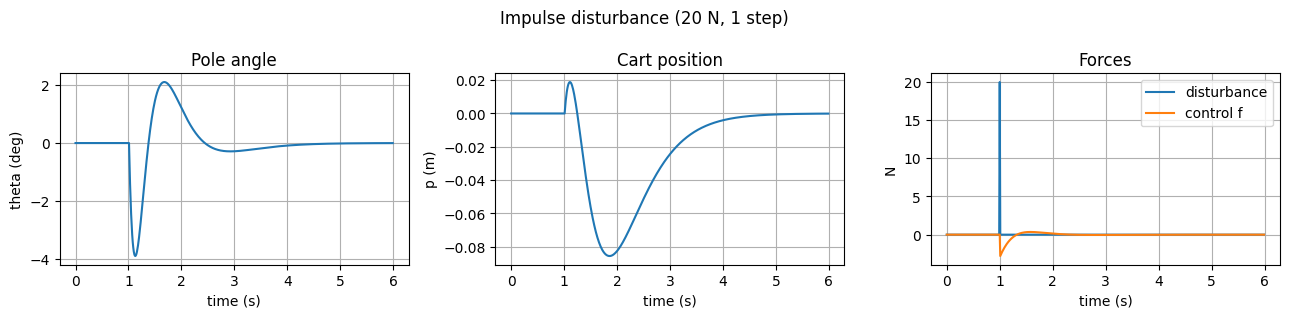

peak |theta| = 3.90 deg, theta at 6 s = -0.0021 deg, cart at 6 s = -0.0001 m


In [4]:
impulse = np.zeros(n)
impulse[100] = 20.0          # one-step knock at t = 1 s
t, X, F = simulate(impulse)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
ax[0].plot(t, np.rad2deg(X[:, 2])); ax[0].set(title='Pole angle', xlabel='time (s)', ylabel='theta (deg)'); ax[0].grid(True)
ax[1].plot(t, X[:, 0]); ax[1].set(title='Cart position', xlabel='time (s)', ylabel='p (m)'); ax[1].grid(True)
ax[2].plot(t, impulse, label='disturbance'); ax[2].plot(t, F, label='control f')
ax[2].set(title='Forces', xlabel='time (s)', ylabel='N'); ax[2].legend(); ax[2].grid(True)
fig.suptitle('Impulse disturbance (20 N, 1 step)'); fig.tight_layout(); plt.show()

print('peak |theta| = %.2f deg, theta at 6 s = %.4f deg, cart at 6 s = %.4f m' %
      (np.max(np.abs(np.rad2deg(X[:, 2]))), np.rad2deg(X[-1, 2]), X[-1, 0]))

**Expected output.** The pole spikes to about **3.9 deg** then returns to upright; by 6 s both the
angle (~0 deg) and the cart (~0 m) are back home. An impulse injects energy *once*, so a stable
controller simply dissipates it — impulses are the **easiest** disturbance to reject.

## Part 2 - Constant disturbance: the steady-state offset

Now a steady 2 N push starting at $t=1$ s. Watch the **cart position**.

**Task:** simulate a constant 2 N disturbance and compare the final cart position to the
closed-form prediction $x_\text{ss} = -(A-BK)^{-1} B\,d$.

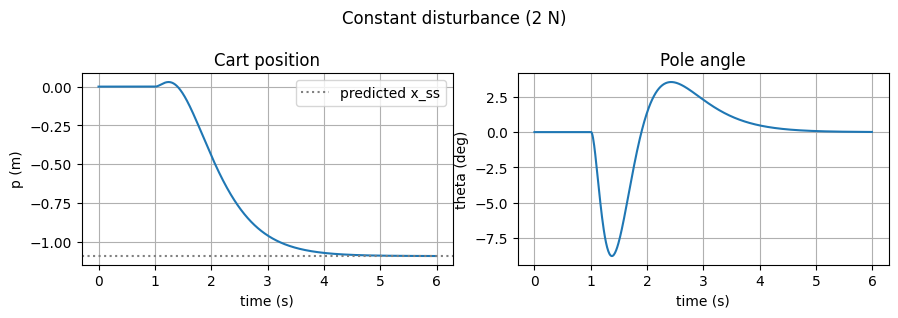

cart at 6 s     = -1.0896 m
predicted x_ss  = -1.0900 m
pole at 6 s     = 0.0104 deg


In [5]:
constant = np.where(np.arange(n) >= 100, 2.0, 0.0)
t, X, F = simulate(constant)

# Closed-form steady state for the linear model: (A - BK) x_ss = -B d
x_ss = -np.linalg.solve(A - np.outer(B.ravel(), K), B.ravel() * 2.0)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(t, X[:, 0]); ax[0].axhline(x_ss[0], color='gray', ls=':', label='predicted x_ss')
ax[0].set(title='Cart position', xlabel='time (s)', ylabel='p (m)'); ax[0].legend(); ax[0].grid(True)
ax[1].plot(t, np.rad2deg(X[:, 2])); ax[1].set(title='Pole angle', xlabel='time (s)', ylabel='theta (deg)'); ax[1].grid(True)
fig.suptitle('Constant disturbance (2 N)'); fig.tight_layout(); plt.show()

print('cart at 6 s     = %.4f m' % X[-1, 0])
print('predicted x_ss  = %.4f m' % x_ss[0])
print('pole at 6 s     = %.4f deg' % np.rad2deg(X[-1, 2]))

**Expected output.** The pole stays upright (~0 deg), but the **cart parks at about -1.09 m** and
stays there — exactly the closed-form $x_\text{ss}$. With pure state feedback $f=-Kx$, a constant
disturbance produces a **constant steady-state error**: the controller needs a steady force to
oppose the push, and the only way it can generate one is by sitting at a nonzero $x$. This is the
classic motivation for **integral action** (Part 4).

## Part 3 - Ramp and noise

**Task:** run a ramp (force growing at 1 N/s after $t=1$ s) and a random-noise disturbance
(std 0.5 N). For each, note what happens to the cart and pole, and decide **which disturbance type
is hardest** for this controller and why.

ramp: cart at 6 s = -2.020 m, pole at 6 s = -0.0026 deg
noise: cart RMS = 0.0158 m, pole RMS = 0.4398 deg


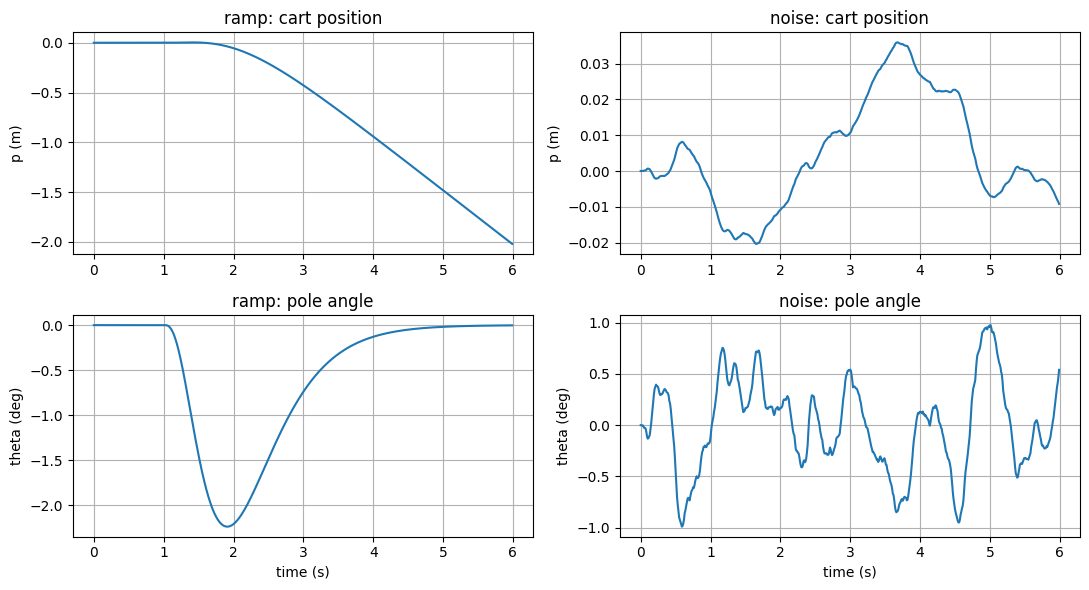

In [6]:
ramp = np.clip(np.arange(n) - 100, 0, None) * dt * 1.0      # 1 N/s after t=1s
rng = np.random.default_rng(0)
noise = 0.5 * rng.standard_normal(n)                         # std 0.5 N

fig, ax = plt.subplots(2, 2, figsize=(11, 6))
for col, (name, dist) in enumerate([('ramp', ramp), ('noise', noise)]):
    t, X, F = simulate(dist)
    ax[0, col].plot(t, X[:, 0]); ax[0, col].set(title=f'{name}: cart position', ylabel='p (m)'); ax[0, col].grid(True)
    ax[1, col].plot(t, np.rad2deg(X[:, 2])); ax[1, col].set(title=f'{name}: pole angle', xlabel='time (s)', ylabel='theta (deg)'); ax[1, col].grid(True)
    if name == 'ramp':
        print('ramp: cart at 6 s = %.3f m, pole at 6 s = %.4f deg' % (X[-1, 0], np.rad2deg(X[-1, 2])))
    else:
        print('noise: cart RMS = %.4f m, pole RMS = %.4f deg' %
              (np.sqrt(np.mean(X[:, 0]**2)), np.sqrt(np.mean(np.rad2deg(X[:, 2])**2))))
fig.tight_layout(); plt.show()

**Expected output.** Under the **ramp** the cart keeps sliding (about **-2.0 m** by 6 s) and grows
without bound, because the disturbance itself never stops growing — a ramp is the **hardest** of
these for pure state feedback (even integral action only removes a *constant* error, not a ramp).
Under **noise** the pole jitters a little (RMS ~0.44 deg) but stays near upright; zero-mean noise
averages out and is mostly a nuisance, not a stability threat.

## Part 4 - Mitigation: integral action

To kill the constant-disturbance offset from Part 2, augment the state with the **integral of cart
position** $x_I = \int p\,dt$ and place poles for the 5-state system. The extra integrator forces
the steady-state cart error to zero.

**Task:** build the augmented system, place 5 poles, and re-run the constant 2 N disturbance.

Kx = [-15.963  -9.205 -34.906  -5.762]  ki = -11.009


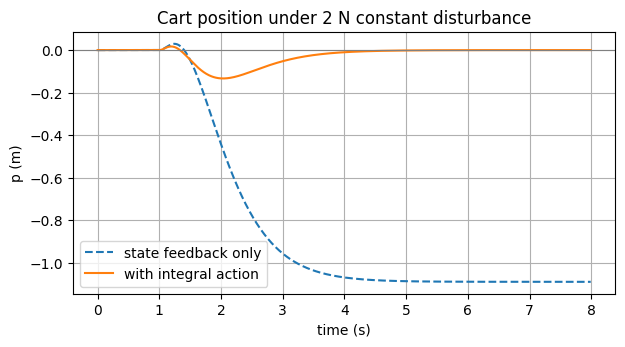

cart at 8 s  no integral: -1.0900 m   with integral: -0.00001 m


In [7]:
# Augment with integral of cart position: x_I_dot = p
C = np.array([[1, 0, 0, 0]])
A_aug = np.block([[A, np.zeros((4, 1))], [C, np.zeros((1, 1))]])
B_aug = np.vstack([B, np.zeros((1, 1))])
K_aug = signal.place_poles(A_aug, B_aug, [-2, -3, -4, -5, -6]).gain_matrix.ravel()
Kx, ki = K_aug[:4], K_aug[4]
print('Kx =', np.round(Kx, 3), ' ki =', round(ki, 3))

def simulate_integral(disturbance, T=8.0, plant='nonlinear'):
    n = int(T / dt)
    x = np.zeros(4); xi = 0.0
    X = np.zeros((n, 4))
    for k in range(n):
        f = float(-Kx @ x - ki * xi)
        X[k] = x
        total = f + disturbance[k]
        x = x + dt * (A @ x + B.ravel() * total if plant == 'linear' else f_nonlin(x, total))
        xi = xi + dt * x[0]
    return np.arange(n) * dt, X

n8 = int(8.0 / dt)
constant8 = np.where(np.arange(n8) >= 100, 2.0, 0.0)
t2, Xi = simulate_integral(constant8)
t2, X0, _ = simulate(constant8, T=8.0)            # no-integral baseline for comparison

plt.figure(figsize=(7, 3.4))
plt.plot(t2, X0[:, 0], '--', label='state feedback only')
plt.plot(t2, Xi[:, 0], label='with integral action')
plt.axhline(0, color='gray', lw=0.8)
plt.title('Cart position under 2 N constant disturbance')
plt.xlabel('time (s)'); plt.ylabel('p (m)'); plt.legend(); plt.grid(True); plt.show()

print('cart at 8 s  no integral: %.4f m   with integral: %.5f m' % (X0[-1, 0], Xi[-1, 0]))

**Expected output.** With integral action the cart returns to **~0 m** under the same 2 N push
(vs the **-1.09 m** offset without it). The integrator accumulates the position error and supplies
the steady opposing force, so the cart no longer has to sit off-target to balance the disturbance.

## Part 5 - Watch the rejection (animation)

Animate the integral controller shrugging off the constant 2 N push: the cart dips, then the
integrator pulls it back to the origin while the pole stays upright.

In [8]:
from matplotlib import animation
from IPython.display import HTML

frames = Xi[::15]            # reuse the integral-action run from Part 4 (8 s)
fig, ax = plt.subplots(figsize=(6, 3))
ax.set_ylim(-0.15, 0.55); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_title('Constant disturbance rejection (integral control)'); ax.set_xlabel('x (m)')
cart = plt.Rectangle((-0.12, 0.0), 0.24, 0.12, fc='steelblue', ec='k'); ax.add_patch(cart)
pole, = ax.plot([], [], lw=3, color='crimson')
bob,  = ax.plot([], [], 'o', color='crimson', ms=9)
ax.axvline(0.0, color='green', ls=':', lw=1)

def _update(i):
    p, th = frames[i, 0], frames[i, 2]
    cart.set_xy((p - 0.12, 0.0))
    tip_x, tip_y = p + L * np.sin(th), 0.12 + L * np.cos(th)
    pole.set_data([p, tip_x], [0.12, tip_y]); bob.set_data([tip_x], [tip_y])
    ax.set_xlim(p - 0.8, p + 0.8)
    return cart, pole, bob

anim = animation.FuncAnimation(fig, _update, frames=len(frames), interval=60, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())

---
## Checkpoints
- Impulse: pole spikes (~4 deg) then recovers to upright; cart returns to ~0.
- Constant: cart settles at a nonzero offset that matches $-(A-BK)^{-1}B d$ (~-1.09 m for 2 N).
- Ramp drives the cart away without bound; noise causes only small jitter.
- Integral action removes the constant-disturbance cart offset (cart -> ~0 m).

## Common pitfalls
- **Disturbance magnitude too large/small.** Pick sizes that reveal behavior without flipping the
  pole (which leaves the linear regime entirely).
- **Expecting integral action to beat a ramp.** Integral action zeroes a *constant* error, not a
  growing one.
- **Wrong integral sign / windup.** Place the augmented poles (don't hand-pick `ki`); a hand-tuned
  integral term easily destabilizes the loop.
- **Reading noise as instability.** Zero-mean jitter is not divergence — check the trend, not the wiggle.